# Welcome to the Part 1 of SA and Agentic AI Tutorial: Hand on LLM4SA

> **Authors:** Karthik Vaidhyanathan and Henry Muccini

> The website of the tutorial can be found here: [https://genai-da.vercel.app/](https://genai-da.vercel.app/)

The first step is to decide on an LLM model. To keep it simple, we are relying on a third-party model. Since it's a tutorial and we want everyone to easily access it, we use the Gemini Model. To use the Gemini model, you would need the key. Below, we explain how to get a key and use the free 2.0 flash model.

## Setup Gemini Key

1. Go to Google AiStudio Api Key
2. Generate Key.
3. Provide any necessary permissions when prompted.

### Adding Your API Key to Colab
1. Open your Google Colab notebook.
2. On the left panel, click the 🔑 “Secrets” icon.
3. Click “+ Add a new secret”.
4. ‘Name’ is you key name, and ‘Value’ is the key
5. Configure the API Key in Your Code
6. Change the name in the 4th cell if needed: GOOGLE_API_KEY=userdata.get(‘Key_Name’)
7. Colab will ask for permission to access your secrets. Grant access to proceed.

In [ ]:
# Import the Python SDK
import google.generativeai as genai
# Used to securely store your API key
from google.colab import userdata
#GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
GOOGLE_API_KEY = "YOUR_API_KEY_HERE"
genai.configure(api_key=GOOGLE_API_KEY)

In [17]:
# Initialize the Gemini API
gemini_model = genai.GenerativeModel('gemini-2.5-flash')

## Introduction to Zero-shot Prompting

Zero-shot prompting is a technique of asking the LLM a question (prompt) without giving any examples to it. The "zero" in zero-shot implies zero examples. So just ask an LLM a question and the model generates an answer based on its prior knowledge that it has from training

In [18]:
def zero_shot_generator(user_prompt):
  """
  Takes a task and returns the model's response.

  Args:
    task: The input task string.

  Returns:
    The response text from the generative model.
  """
  response = gemini_model.generate_content(user_prompt)
  return response.text

In [19]:
user_prompt = "What is software architecture"
response = zero_shot_generator (user_prompt)
print(response)

BadRequest: 400 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: API key not valid. Please pass a valid API key.

## Architecture Decision Record (ADR) Generation

ADR helps us to capture architecture design decisions using simple markdown files. If you are interested in knowing more. [Check out this article.](https://cognitect.com/blog/2011/11/15/documenting-architecture-decisions.html)

Now, let us assume that we want to generate ADR given a decision context. One way is to simply use zero-shot prompting. Lets take a simple example here.

In [ ]:
def zero_shot_generator_ADR(user_prompt):
  """
  Takes a task and returns the model's response.

  Args:
    task: The input task string.

  Returns:
    The response text from the generative model.
  """

  response = gemini_model.generate_content(user_prompt)
  return response.text

In [ ]:
user_prompt = "I am thinking of python vs R for building machine learning. I want to think about an ADR for this"
response = zero_shot_generator_ADR(user_prompt)
print(response)

Okay, let's outline an Architecture Decision Record (ADR) comparing Python and R for machine learning. Here's a template and a breakdown of the considerations to include.

**ADR Template (Example)**

```markdown
# ADR: Python vs. R for Machine Learning

* **Status:** Proposed
* **Date:** 2023-10-27
* **Author:** [Your Name]

## 1. Context

Our team is embarking on a new machine learning project. We need to choose a primary programming language for developing, training, and deploying models.  The primary contenders are Python and R. This ADR evaluates both options to determine the best fit for our needs.

## 2. Decision

[**Choose one of these options, and elaborate in the Consequences section:**]

*   **Option A: Adopt Python as the primary language for machine learning.**
*   **Option B: Adopt R as the primary language for machine learning.**
*   **Option C: Adopt a hybrid approach, using Python for [specific tasks] and R for [specific tasks].**
*   **Option D: Defer the decision and 

## Adding System Prompt to Zero-shot Prompting - ADR Generation

Now let us assume that we want the model to generate an [Architecture Decision Record](https://cognitect.com/blog/2011/11/15/documenting-architecture-decisions.html) for a given context or anything where we want the model to follow a format or use a particular style while responding. One way is to just give a prompt and expect the model to figure it out but it may not work always as the general purpose models have all the world knowledge so its important to tell them specifically how something has to be done. For this we can make use of system prompt.

In [ ]:
def adr_generator_with_system_prompt(user_prompt):
    """
    Generates an Architecture Decision Record (ADR) using a system prompt + user prompt.

    Args:
      user_prompt (str): The specific task or decision context provided by the user.

    Returns:
      str: The ADR formatted response from the generative model.
    """

    system_prompt = """
    You are an expert software architect.
    Always respond in the format of an Architecture Decision Record (ADR).
    The ADR must have the following sections:
    1. Title
    2. Context
    3. Decision
    4. Status
    5. Consequences

    The context is the prompt provided by the user

    Keep the ADR clear, concise, and professional.
    """

    response = gemini_model.generate_content(
        [
            {"role": "model", "parts": [system_prompt]},
            {"role": "user", "parts": [user_prompt]}
        ]
    )

    return response.text

In [ ]:
prompt = "I am thinking of python vs R for building machine learning. I want to think about an ADR for this"
response = adr_generator_with_system_prompt(prompt)
print(response)

## Architecture Decision Record: Python vs. R for Machine Learning

### 1. Title
Choose Python as the primary language for Machine Learning projects.

### 2. Context
We need to select a primary programming language for developing and deploying machine learning models. The main contenders are Python and R, both widely used in the field of data science. 

*   **Python:** Python is a general-purpose programming language known for its readability, extensive libraries, and large community support. It is widely used in various domains, including web development, scripting, and data science.
*   **R:** R is a programming language and environment specifically designed for statistical computing and graphics. It has a rich ecosystem of packages for statistical analysis and data visualization.

We must consider factors such as ease of use, library availability, deployment options, community support, and integration with existing systems.

### 3. Decision
We will adopt Python as the primary langua

## Improving the ADR Generation (May not be always) with Few-Shot Prompting

In zero-shot the idea was that we are just leveraging the knowledge of LLMs to get a prompt answered. But we may want the LLMs to see some sample ADRs to get an idea for generating new ADRs for a given context. In such scenarios, we use few-shot prompting. The idea here is to give a few examples along with the prompt to generate the final response.

When we prompt an LLM using few shots, something called In-Context Learning comes into the effect and due to which we feel that the LLMs are able to learn from the examples given.

In [ ]:
def adr_generator_few_shot(user_prompt):
    """
    Generates an Architecture Decision Record (ADR) using few-shot examples.

    Args:
      user_prompt (str): The specific task or decision context provided by the user.

    Returns:
      str: The ADR formatted response from the generative model.
    """

    # Few-shot examples (more can be added)
    examples = """
    Example 1:
    ## Context

Arachne has a number of goals.

1. It needs to be *modular*. Different software packages, written by
   different developers, should be usable and swappable in the same
   application with a minimum of effort.

2. Arachne applications need to be *transparent* and
   *introspectable*. It should always be as clear as possible what is
   going on at any given moment, and why the application is behaving
   in the way it does.

3. As a general-purpose web framework, it needs to provide a strong
   set of default settings which are also highly overridable, and
   *configurable* to suit the unique needs of users.


Also, it is a good development practice (particularly in Clojure) to
code to a specific information model (that is, data) rather than to
particular functions or APIs. Along with other benefits, this helps
separate (avoids "complecting") the intended operation and its
implementation.

Documenting the full rationale for this "data first" philosophy is
beyond the scope of this document, but some resources that explain it (among other things) are:

- [Simple Made Easy](http://www.infoq.com/presentations/Simple-Made-Easy) - Rich Hickey
- [Narcissistic Design](https://vimeo.com/77199361) - Stuart Halloway
- [Data Beats Functions](https://malcolmsparks.com/posts/data-beats-functions.html) - Malcolm Sparks
- [Always Be Composing](https://www.youtube.com/watch?v=3oQTSP4FngY) - Zach Tellman
- [Data > Functions > Macros](http://www.lispcast.com/data-functions-macros-why) - Eric Normand

Finally, one weakness of many existing Clojure libraries, especially
web development libraries, is the way in which they overload the
Clojure runtime (particularly vars and reified namespaces) to store
information about the webapp. Because both the Clojure runtime and
many web application entities (e.g servers) are stateful, this causes
a variety of issues, particularly with reloading namespaces. Therefore,
as much as possible, we would like to avoid entangling information
about an Arachne application with the Clojure runtime itself.

## Decision

Arachne will take the "everything is data" philosophy to its logical
extreme, and encode as much information about the application as
possible in a single, highly general data structure. This will include
not just data that is normally thought of as "config" data, but the
structure and definition of the application itself. Everything that
does not have to be arbitrary executable code will be
reflected in the application config value.

Some concrete examples include (but are not limited to):

- Dependency injection components
- Runtime entities (servers, caches, connections, pools, etc)
- HTTP routes and middleware
- Persistence schemas and migrations
- Locations of static and dynamic assets

This configuration value will have a *schema* that defines what types
of entities can exist in the configuration, and what their expected
properties are.

Each distinct module will have the ability to contribute to the schema
and define entity types specific to its own domain. Modules may
interact by referencing entity types and properties defined in other
modules.

Although it has much in common with a fully general in-memory
database, the configuration value will be a single immutable value,
not a stateful data store. This will avoid many of the complexities
of state and change, and will eliminate the temptation to use the
configuration itself as dynamic storage for runtime data.

## Status

Proposed

## Consequences

- Applications will be defined comprehensively and declaratively by a
  rich data structure, before the application even starts.
- The config schema provides an explicit, reliable contract and set of
  extension points, which can be used by other modules to modify
  entities or behaviors.
- It will be easy to understand and inspect an application by
  inspecting or querying its configuration. It will be possible to
  write tools to make exploring and visualizing applications even easier.
- Developers will need to carefully decide what types of things are
  appropriate to encode statically in the configuration, and what must
  be dynamic at runtime.

  Example 2:
  Context
One design goal of Arachne is to have modules be relatively easily swappable. Users should not be permanently committed to particular technical choices, but instead should have some flexibility in choosing their preferred tech, as long as it exists in the form of an Arachne module.

Some examples of the alternative implementations that people might wish to use for various parts of their application:

HTTP Server: Pedestal or Ring
Database: Datomic, an RDBMS or one of many NoSQL options.
HTML Templating: Hiccup, Enlive, StringTemplate, etc.
Client-side code: ClojureScript, CoffeeScript, Elm, etc.
Authentication: Password-based, OpenID, Facebook, Google, etc.
Emailing: SMTP, one of many third-party services.
This is only a representative sample; the actual list is unbounded.

The need for this kind of flexibility raises some design concerns:

Capability. Users should always be able to leverage the full power of their chosen technology. That is, they should not have to code to the "least common denominator" of capability. If they use Datomic Pro, for example, they should be able to write Datalog and fully utilize the in-process Peer model, not be restricted to an anemic "ORM" that is also compatible with RDBMSs.

Uniformity. At tension with capability is the desire for uniformity; where the feature set of two alternatives is not particularly distinct, it is desirable to use a common API, so that implementations can be swapped out with little or no effort. For example, the user-facing API for sending a single email should (probably) not care whether it is ultimately sent via a local Sendmail server or a third-party service.

Composition. Modules should also compose as much as possible, and they should be as general as possible in their dependencies to maximize the number of compatible modules. In this situation, it is actually desirable to have a "least common denominator" that modules can have a dependency on, rather than depending on specific implementations. For example, many modules will need to persist data and ultimately will need to work in projects that use Datomic or SQL. Rather than providing multiple versions, one for Datomic users and another for SQL, it would be ideal if they could code against a common persistence abstraction, and therefore be usable in any project with a persistence layer.

What does it mean to use a module?
The following list enumerates the ways in which it is possible to "use" a module, either from a user application or from another module. (See ADR-004).

You can call code that the module provides (the same as any Clojure library.)
You can extend a protocol that the module provides (the same as any Clojure library.)
You can read the attributes defined in the module from the configuration.
You can write configuration data using the attributes defined in the module.
These tools allow the definition of modules with many different kinds of relationships to each other. Speaking loosely, these relationships can correspond to other well-known patterns in software development including composition, mixins, interface/implementation, inheritance, etc.

Decision
In order to simultaneously meet the needs for capability, uniformity and composition, Arachne's core modules will (as appropriate) use the pattern of abstract modules.

Abstract modules define certain attributes (and possibly also corresponding init script DSLs) that describe entities in a particular domain, without providing any runtime implementation which uses them. Then, other modules can "implement" the abstract module, reading the abstract entities and doing something concrete with them at runtime, as well as defining their own more specific attributes.

In this way, user applications and dependent modules can rely either on the common, abstract module or the specific, concrete module as appropriate. Coding against the abstract module will yield a more generic "least common denominator" experience, while coding against a specific implementor will give more access to the unique distinguishing features of that particular technology, at the cost of generality.

Similar relationships should hold in the library code which modules expose (if any.) An abstract module, for example, would be free to define a protocol, intended to be implemented concretely by code in an implementing module.

This pattern is fully extensible; it isn't limited to a single level of abstraction. An abstract module could itself be a narrowing or refinement of another, even more general abstract module.

Concrete Example
As mentioned above, Arachne would like to support both Ring and Pedestal as HTTP servers. Both systems have a number of things in common:

The concept of a "server" running on a port.
The concept of a URL path/route
The concept of a terminal "handler" function which receives a request and returns a response.
They also have some key differences:

Ring composes "middleware" functions, whereas Pedestal uses "interceptor" objects
Asynchronous responses are handled differently
Therefore, it makes sense to define an abstract HTTP module which defines the basic domain concepts; servers, routes, handlers, etc. Many dependent modules and applications will be able to make real use of this subset.

Then, there will be the two modules which provide concrete implementations; one for Pedestal, one for Ring. These will contain the code that actually reads the configuration, and at runtime builds appropriate routing tables, starts server instances, etc. Applications which wish to make direct use of a specific feature like Pedestal interceptors may freely do so, using attributes defined by the Pedestal module.

Status
PROPOSED

Consequences
If modules or users want to program against a "lowest common denominator" abstraction, they may do so, at the cost of the ability to use the full feature set of a library.
If modules or users want to use the full feature set of a library, they may do so, at the cost of being able to transparently replace it with something else.
There will be a larger number of different Arachne modules available, and their relationships will be more complex.
Careful thought and architecture will need to go into the factoring of modules, to determine what the correct general elements are.
    """

    response = gemini_model.generate_content(
        [
            {"role": "user", "parts": [f"You are an expert architect. Always respond in ADR format. Here are some examples:\n{examples}"]},
            {"role": "user", "parts": [f"Now generate an ADR for this task:\n{user_prompt}"]}
        ]
    )

    return response.text

In [ ]:
user_prompt_fewshot = "Context: We need to decide whether to adopt a message queue (Kafka) for asynchronous communication in our microservices."
reponse = adr_generator_few_shot(user_prompt_fewshot)
print (response)

## Architecture Decision Record: Python vs. R for Machine Learning

### 1. Title
Choose Python as the primary language for Machine Learning projects.

### 2. Context
We need to select a primary programming language for developing and deploying machine learning models. The main contenders are Python and R, both widely used in the field of data science. 

*   **Python:** Python is a general-purpose programming language known for its readability, extensive libraries, and large community support. It is widely used in various domains, including web development, scripting, and data science.
*   **R:** R is a programming language and environment specifically designed for statistical computing and graphics. It has a rich ecosystem of packages for statistical analysis and data visualization.

We must consider factors such as ease of use, library availability, deployment options, community support, and integration with existing systems.

### 3. Decision
We will adopt Python as the primary langua

## ADR Generation using Retrieval Augmented Generation (RAG)

Most of the times as an organization, we may have some ADRs that we have written and we may want the LLM to follow the similar pattern as well as insights from it when generating new ADRs.



### Loading the data and creating the embeddings

First step is to have a set of ADRs that can be used as a knowledge base. For simplicity, we have selected three ADRs from [here](https://github.com/joelparkerhenderson/architecture-decision-record/tree/main?tab=readme-ov-file).

You can download the ADRs that we will be using for this example from [this link](https://www.dropbox.com/scl/fo/82w75ylrlphctmqudmv0f/ADND0o8kvp4qkH0rDAkT2u8?rlkey=icmv957lx51pqswg2m7ve2pz6&st=awfwnez4&dl=0)

1. Create a folder "adrs" under the Files section on the left side
2. Upload the downloaded adrs to the adrs directory

In [ ]:
!wget -O dropbox_folder.zip "https://www.dropbox.com/scl/fo/82w75ylrlphctmqudmv0f/ADND0o8kvp4qkH0rDAkT2u8?rlkey=icmv957lx51pqswg2m7ve2pz6&st=awfwnez4&dl=1"
!mkdir adrs
!unzip -j dropbox_folder.zip -d adrs

--2026-01-28 10:31:10--  https://www.dropbox.com/scl/fo/82w75ylrlphctmqudmv0f/ADND0o8kvp4qkH0rDAkT2u8?rlkey=icmv957lx51pqswg2m7ve2pz6&st=awfwnez4&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc2235c2c231c8cc425cbc3fa71f.dl.dropboxusercontent.com/zip_download_get/CdPCwPGaI4Z_ibyFQmGWM_ssjQL6QWNLC7vKYrNqIqufpmoOxjXTMqrADLvfArZ6D9pPt2RYjnAoLE9CDzKY40wNR0v2kxHXM63arSN66Trfwg# [following]
--2026-01-28 10:31:11--  https://uc2235c2c231c8cc425cbc3fa71f.dl.dropboxusercontent.com/zip_download_get/CdPCwPGaI4Z_ibyFQmGWM_ssjQL6QWNLC7vKYrNqIqufpmoOxjXTMqrADLvfArZ6D9pPt2RYjnAoLE9CDzKY40wNR0v2kxHXM63arSN66Trfwg
Resolving uc2235c2c231c8cc425cbc3fa71f.dl.dropboxusercontent.com (uc2235c2c231c8cc425cbc3fa71f.dl.dropboxusercontent.com)... 162.125.1.15, 2620:100:601c:15::a27d:60f
Connecting to uc2235c2c231c8cc425cb

In [ ]:
!pip install faiss-cpu sentence-transformers -q
import os
import glob
from sentence_transformers import SentenceTransformer
import faiss

# 1. Load ADR markdowns
adr_docs = []
for file in glob.glob("adrs/*.md"):
    with open(file, "r") as f:
        adr_docs.append(f.read())

# 2. Create embeddings
embedder = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedder.encode(adr_docs, convert_to_tensor=False)

# 3. Build FAISS index
dim = embeddings[0].shape[0]
index = faiss.IndexFlatL2(dim)
index.add(embeddings)

print(f"Indexed {len(adr_docs)} ADRs.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 62.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Indexed 3 ADRs.


## Checking out the retriever

Once we have stored the embeddings, the next step is to check if the retireval is working fine. For this the below snippet takes in a query and returns the top 2 results (k=2) that are similar to the query

In [ ]:
def retrieve_adr(query, top_k=2):
    query_emb = embedder.encode([query])
    distances, indices = index.search(query_emb, top_k)
    results = [adr_docs[i] for i in indices[0]]
    return results

In [ ]:
query = "Selecting a programming language"
results = retrieve_adr(query)
print(results)

["Architecture Decision Record: Go programming language\nTitle: Adoption of Go Programming Language\n\nStatus: Accepted\n\nContext\nOur organization has been primarily using Java programming language for building web applications. However, we have been experiencing some challenges due to Java's verbosity and the complexity of some frameworks. Also, our team has shown interest in exploring modern programming languages for more efficient and robust development. After conducting research, we have identified Go as a potential solution to the problems we face with Java.\n\nDecision\nWe will adopt Go programming language for building web applications going forward.\n\nRationale\nSimplicity and readability: Go is known for its simplicity and concise syntax. This makes it easy to read and write code, reducing the complexity of our development process.\n\nHigh-performance and scalability: Go is compiled into machine code that runs natively on the server. This results in faster execution times a

## ADR Generation using RAG

The function below takes as input a query, which is the context for the ADR in our case. It then finds the top 2 results using the retrieval function. Then applies LLM on the retrieved results to generate the final response. This ensures that the ADR generated is based on the patterns followed in the set of ADRs.

This will also ensure that the ADR is generated keeping in mind the previous decisions for similar contexts.


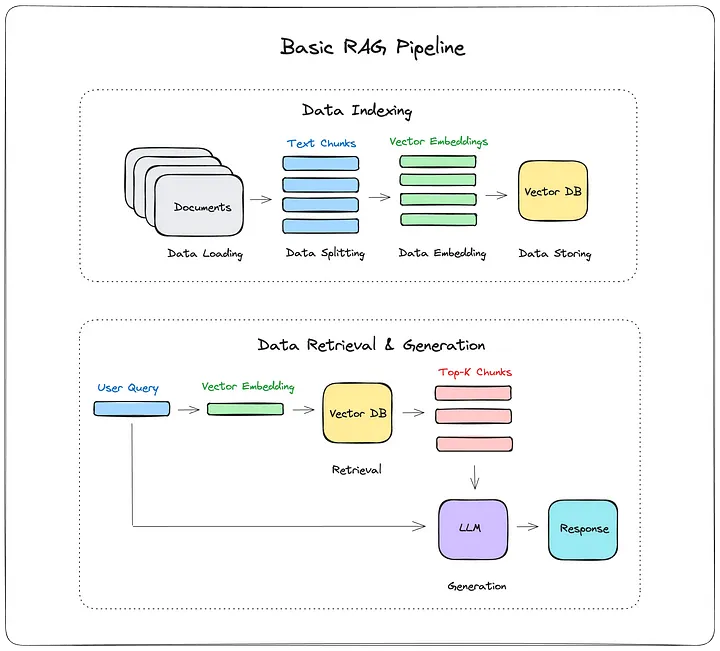



Image source: [https://medium.com/@drjulija/what-is-retrieval-augmented-generation-rag-938e4f6e03d1](https://medium.com/@drjulija/what-is-retrieval-augmented-generation-rag-938e4f6e03d1)

In [ ]:
def rag_adr(query):
    retrieved = retrieve_adr(query)
    context_text = "\n\n".join(retrieved)

    prompt = f"""
You are an expert software architect. Use the following ADRs as context:

{context_text}

Now answer the query: {query}
Always provide output in ADR format (Title, Context, Decision, Status, Consequences).
"""
    response = gemini_model.generate_content(prompt)
    return response.text

In [ ]:
rag_user_prompt = "I want to select a programming language for my system between Go and Java"
rag_response = rag_adr(rag_user_prompt)
print(rag_response)

Okay, I understand. Based on the provided ADRs and your desire to select a programming language between Go and Java, here's an ADR draft.  Please note that I am making a specific decision here (Go) based on the context of the existing ADR for Go adoption. You might want to adjust the decision and rationale if your specific requirements differ.

```
# Architecture Decision Record: Programming Language Selection: Go vs. Java

## Title

Programming Language Selection: Go vs. Java

## Context

We are currently building a new system. We have experience with both Java and, based on [ADR-001 Adoption of Go Programming Language](adr-001-go-adoption.md), a growing familiarity with Go. We need to select a primary programming language for this new system.

[ADR-001](adr-001-go-adoption.md) highlights the benefits of Go (simplicity, performance, scalability, community, flexibility) as a driver for its adoption within the organization. However, Java has been our primary language historically, and w

## Fine-Tuning LLMs to generate Architecture Decision Record

There are situations where RAG is not enough, and we often as organisations don't want to rely on third-party API providers due to privacy issues, as well as cost. In such situations, if we have "enough" data, we can fine-tune a model for a specific task.

Below, we demonstrate how we can fine-tune a small model.

In [ ]:
!pip install transformers datasets accelerate -q

In [ ]:
import json

adr_data = [
    {
        "context": "We need to decide between REST and gRPC for service communication.",
        "adr": """Title: Choose REST for Service Communication
Context: Services must be exposed to third-party clients with wide compatibility.
Decision: Adopt REST over HTTP for inter-service and external communication.
Status: Accepted
Consequences: Easy integration and debugging, but less efficient than gRPC for high-throughput scenarios."""
    },
    {
        "context": "The system requires a database for strong consistency and ACID compliance.",
        "adr": """Title: Adopt PostgreSQL as Primary Database
Context: The platform needs reliable transactions and advanced querying.
Decision: Use PostgreSQL as the primary relational database.
Status: Accepted
Consequences: Supports strong consistency and SQL features, but horizontal scaling may require sharding."""
    },
    {
        "context": "We need to support asynchronous communication between microservices.",
        "adr": """Title: Introduce Kafka for Asynchronous Communication
Context: Services should not block on request/response patterns.
Decision: Use Apache Kafka as the messaging backbone.
Status: Proposed
Consequences: Enables loose coupling and scalability, but adds operational complexity."""
    }
]

with open("adr_dataset.jsonl", "w") as f:
    for item in adr_data:
        f.write(json.dumps(item) + "\n")


In [ ]:

from datasets import load_dataset

dataset = load_dataset("json", data_files="adr_dataset.jsonl", split="train")
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['context', 'adr'],
    num_rows: 3
})

In [ ]:
from transformers import AutoTokenizer

model_name = "google/flan-t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess(batch):
    inputs = tokenizer(batch["context"], padding="max_length", truncation=True, max_length=256)
    labels = tokenizer(batch["adr"], padding="max_length", truncation=True, max_length=256)
    inputs["labels"] = labels["input_ids"]
    return inputs

tokenized_dataset = dataset.map(preprocess, batched=True, remove_columns=dataset.column_names)


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

In [ ]:
import torch
from transformers import AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Trainer, TrainingArguments
import os
os.environ["WANDB_DISABLED"] = "true"

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

collator = DataCollatorForSeq2Seq(tokenizer, model=model)

training_args = TrainingArguments(
    output_dir="./flan-adr",
    learning_rate=2e-5,
    per_device_train_batch_size=2,
    num_train_epochs=5,   # keeping small for demo
    weight_decay=0.01,
    logging_dir="./logs",
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=collator
)

trainer.train()


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-2035761222.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


TrainOutput(global_step=10, training_loss=30.31165771484375, metrics={'train_runtime': 108.8974, 'train_samples_per_second': 0.138, 'train_steps_per_second': 0.092, 'total_flos': 1394178785280.0, 'train_loss': 30.31165771484375, 'epoch': 5.0})

In [ ]:
test_input = "The system requires a database for strong consistency and ACID compliance."
inputs = tokenizer(test_input, return_tensors="pt")
output = model.generate(**inputs, max_length=200)
print(tokenizer.decode(output[0], skip_special_tokens=True))

The system requires a database for strong consistency and ACID compliance.


## Evaluation of ADR Generation

When training or prompting models, we want to know how well the generated ADR matches an expected “gold” ADR. Common NLP metrics:

**BLEU:** measures word overlap (good for n-gram precision).

**METEOR** considers synonyms and word order.

**BERTScore** uses contextual embeddings from BERT/Transformers, capturing semantic similarity.

Other than this, one can also leverage the concept of LLM-as-judge for evaluating where the response and expected response can be sent to an LLM (mostly a different or a more powerful one)  for evaluation.



In [ ]:
!pip install evaluate bert-score -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.8 MB/s eta 0:00:00


In [ ]:
import os

# Path to gold ADR (markdown file in adr/ folder)
gold_path = "./adrs/go_adr.md"

with open(gold_path, "r") as f:
    reference_adr = f.read()

print("Reference ADR (gold):\n", reference_adr[:300], "...")

Reference ADR (gold):
 Architecture Decision Record: Go programming language
Title: Adoption of Go Programming Language

Status: Accepted

Context
Our organization has been primarily using Java programming language for building web applications. However, we have been experiencing some challenges due to Java's verbosity an ...


In [ ]:
# Example: generate ADR using your zero-shot function
user_prompt = "Our organization has been primarily using Java programming language for building web applications. However, we have been experiencing some challenges due to Java's verbosity"
generated_adr = zero_shot_generator(user_prompt)

print("Generated ADR:\n", generated_adr[:300], "...")

Generated ADR:
 Okay, I understand. Java's verbosity is a common complaint. It can lead to larger codebases, more boilerplate, and increased development time. Let's explore some potential solutions to address this, keeping in mind your goal of building web applications.  To give you the best advice, I need a little ...


In [ ]:
import evaluate

# Load metrics
bleu = evaluate.load("bleu")
meteor = evaluate.load("meteor")
bertscore = evaluate.load("bertscore")

# Wrap as lists for evaluation API
references = [reference_adr]
candidates = [generated_adr]

# Compute scores
bleu_score = bleu.compute(predictions=candidates, references=references)
meteor_score = meteor.compute(predictions=candidates, references=references)
bertscore_result = bertscore.compute(predictions=candidates, references=references, lang="en")

print("BLEU:", bleu_score["bleu"])
print("METEOR:", meteor_score["meteor"])
print("BERTScore (F1):", sum(bertscore_result["f1"]) / len(bertscore_result["f1"]))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BLEU: 0.013449764291446184
METEOR: 0.28538301489957746
BERTScore (F1): 0.8076748251914978


### LLM as Judge for ADR Evaluation

This method leverages a Large Language Model (LLM) itself to act as a judge, evaluating the quality of a generated Architecture Decision Record (ADR) against a reference (gold standard) ADR. The judge LLM is given both ADRs and a set of criteria, and then provides a score and a rationale for its assessment.

This approach can be particularly useful for tasks where objective metrics (like BLEU or BERTScore) might not fully capture the nuance of the content, such as adherence to a specific format, logical coherence, or completeness from an architectural perspective.

In [ ]:
def llm_as_judge(generated_adr: str, reference_adr: str, judge_model=None):
    """
    Evaluates a generated ADR against a reference ADR using an LLM as a judge.

    Args:
        generated_adr (str): The ADR generated by another model.
        reference_adr (str): The gold standard or reference ADR.
        judge_model: The GenerativeModel instance to use as the judge. Defaults to gemini_model.

    Returns:
        str: The judge LLM's evaluation and score.
    """
    if judge_model is None:
        # Assuming gemini_model is already configured and available in the notebook scope
        judge_model = gemini_model

    judge_prompt = f"""
You are an expert software architect and a critical evaluator. Your task is to compare a 'Generated ADR' with a 'Reference ADR' for the same architectural decision.

Evaluate the 'Generated ADR' based on the following criteria:
1.  **Relevance:** How well does the generated ADR address the core decision and context?
2.  **Completeness:** Does it include all necessary sections (Title, Context, Decision, Status, Consequences) and relevant information?
3.  **Accuracy:** Is the information provided factually correct and aligned with architectural best practices (within the given context)?
4.  **Clarity & Conciseness:** Is the language clear, easy to understand, and free of unnecessary jargon or repetition?
5.  **Adherence to Format:** Does it strictly follow the ADR format with the specified sections?
6.  **Overall Quality:** How does the overall quality of the generated ADR compare to the reference?

Here is the Reference ADR:
```
{reference_adr}
```

Here is the Generated ADR:
```
{generated_adr}
```

Provide a score out of 10 for the 'Generated ADR' based on these criteria, and give a detailed justification for your score. Focus on what could be improved in the Generated ADR to match or exceed the Reference ADR. Your response should be structured as follows:

**Score: [X/10]**
**Justification:**
[Your detailed justification here, including specific points for each criterion where applicable and suggestions for improvement.]
"""

    response = judge_model.generate_content(judge_prompt)
    return response.text


In [ ]:
# Assuming 'reference_adr' and 'generated_adr' from previous cells are available
# If not, you might need to re-run the previous cells or define them here.
# For example:
# with open('./adrs/go_adr.md', 'r') as f:
#     reference_adr = f.read()
# user_prompt = "Our organization has been primarily using Java programming language for building web applications. However, we have been experiencing some challenges due to Java's verbosity"
# generated_adr = zero_shot_generator(user_prompt)

# Run the LLM as judge
judge_evaluation = llm_as_judge(generated_adr, reference_adr)
print(judge_evaluation)


**Score: 3/10**

**Justification:**

The generated text, while helpful in a brainstorming context, fails significantly as an Architecture Decision Record (ADR). It resembles a preliminary investigation or a series of questions to clarify the context rather than a record of a *decision* made. It doesn't adhere to the ADR format at all and lacks several crucial elements.

*   **Relevance:** The generated text is tangentially relevant. It acknowledges the problem of Java's verbosity and suggests potential solutions. However, it doesn't *make* a decision. It outlines options without choosing one. A true ADR documents a choice.

*   **Completeness:** The generated text is severely lacking in completeness for an ADR.

    *   It's missing a clear **Title**. The question about verbosity is a problem statement, not a decision.
    *   It's missing a **Status**.
    *   While it explores the **Context** to some extent by asking clarifying questions, it doesn't provide a concise summary of the r

## SA Bench

If you are working on Architecture tasks and you want to contribute to datasets and evaluations in the software architecture community, you can always do that through [sabench.com](https://www.sabench.com/)